# Classical Tipping Problem

I have modified the tutorial at https://pythonhosted.org/scikit-fuzzy/auto_examples/plot_tipping_problem.html.

This problem is the conundrum of how much should you tip you waiter... 

**Input variables**

While dining, lets consider the following variables

  * quality : quality of the food
  * service : quality of the service

**Output variable**

The output (variable) is simply the tip amount, in percentage:

  * tip : percent of bill to add as tip

For the purposes of discussion, let’s say we need ‘high’, ‘medium’, and ‘low’ membership functions for both input variables and our output variable. 

Here is the **cleanest, simplest conceptual explanation** of **how a Mamdani fuzzy logic system works**, using your *restaurant tipping* example.

No math. No code.
Just **conceptual understanding**.

---

# 🌟 **1. Inputs are vague human concepts**

You start with inputs like:

* **Food quality** (0–10)
* **Service quality** (0–10)

These are numbers, but humans describe them as:

* *bad*
* *decent*
* *great*
* *poor*
* *acceptable*
* *amazing*

So you convert numbers → fuzzy meanings.

---

# 🌟 **2. You convert crisp numbers into fuzzy membership degrees**

Example:

Food = 6.5
Service = 7

Instead of saying “food is 6.5,” we say:

* Food is **Decent** with membership **0.7**
* Food is **Great** with membership **0.2**
* Food is **Bad** with membership **0.0**

Same for service.

This step is called **fuzzification**.

---

# 🌟 **3. Fuzzy rules describe human reasoning**

You write rules that sound like real-life logic:

* **Rule 1:** If food is bad OR service is poor → tip is low
* **Rule 2:** If service is acceptable → tip is medium
* **Rule 3:** If service is amazing OR food is great → tip is high

These are the system’s **knowledge**.

---

# 🌟 **4. Use membership degrees to evaluate rule strength**

Example:

If food is “bad” = 0.1
and service is “poor” = 0.3

Then Rule 1 fires with strength:

```
max(0.1, 0.3) = 0.3
```

This means:

> “This rule applies with strength 0.3.”

Each rule produces its own output **strength**.

---

# 🌟 **5. Each rule *activates* an output membership function**

Each rule points to an **output fuzzy set**:

* Rule 1 → Low tip
* Rule 2 → Medium tip
* Rule 3 → High tip

If Rule 1 fires with 0.3, we take the **Low tip membership function** and **cut it (clip it)** at height 0.3.

This is called **implication**.

---

# 🌟 **6. Combine all activated output shapes**

Now you have:

* A clipped Low tip shape (blue)
* A clipped Medium tip shape (green)
* A clipped High tip shape (red)

These three shapes overlap.

You **merge them** using fuzzy OR (max):

```
final_output_function = max(low, medium, high)
```

This gives one final fuzzy shape:
**Your aggregated fuzzy tip output.**

---

# 🌟 **7. Convert fuzzy shape → actual tip (defuzzification)**

The most common method is:

### **Centroid (center of gravity)**

Imagine the final fuzzy shape is a weird mountain.
You balance it on a stick.

Where does it balance?
That x-value is the **crisp tip percent**.

Example result:

> The system says the tip should be **17.8%**.

---

# ✔ **In one sentence**

A fuzzy logic system takes vague human rules, determines how strongly each rule applies to the given situation, generates fuzzy output shapes from those rules, merges them, and computes a final crisp number (like a tip amount).

---

# ✔ **In super-short steps**

1. **Fuzzify:** Convert inputs → fuzzy degrees
2. **Rule evaluation:** Check how strongly each rule fires
3. **Implication:** Clip output membership sets by rule strength
4. **Aggregation:** Combine all outputs
5. **Defuzzify:** Convert final fuzzy shape → real number

---

If you want, I can draw a simple diagram of these 5 stages or walk you through it using your exact input (e.g., food=6.5, service=7).


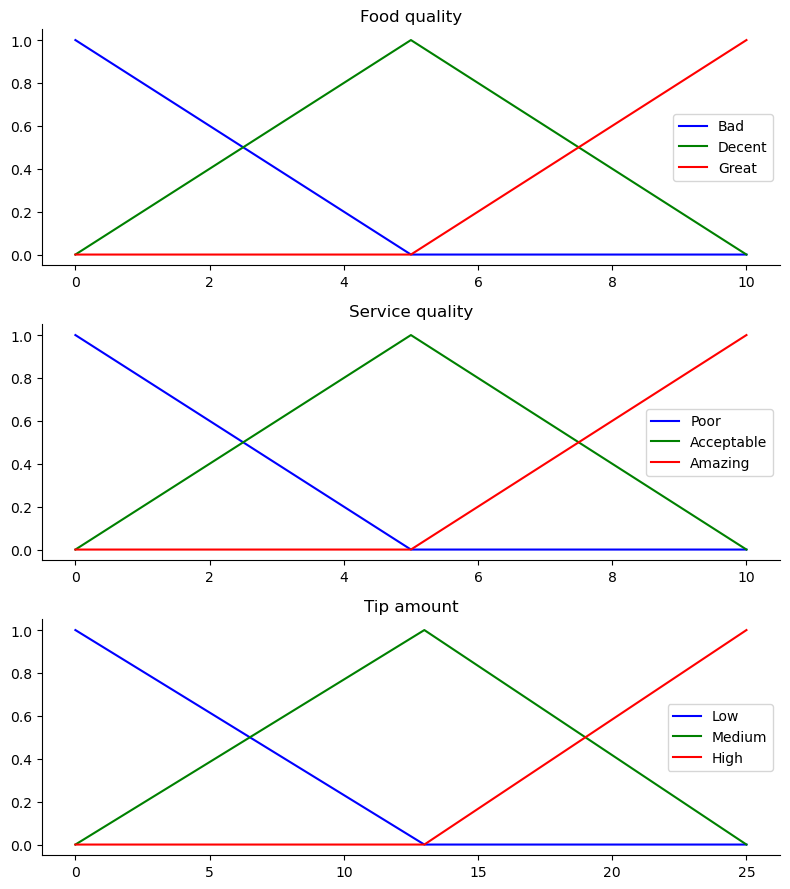

In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Sample values on our universes of discourse, 2 inputs and 1 output
#  quality and service on subjective ranges [0, 10]
#  tip has a range of [0, 25] in units of percentage points

# domain_quality = np.arange(0, 11, 1)
# domain_service = np.arange(0, 11, 1)
# domain_tip  = np.arange(0, 26, 1)

domain_quality = np.linspace(0, 10, 101)
domain_service = np.linspace(0, 10, 101)
domain_tip     = np.linspace(0, 25, 101)

# generate fuzzy membership functions on their corresponding domain.
qual_lo_func = fuzz.trimf(domain_quality, [0, 0, 5])
qual_md_func = fuzz.trimf(domain_quality, [0, 5, 10])
qual_hi_func = fuzz.trimf(domain_quality, [5, 10, 10])
serv_lo_func = fuzz.trimf(domain_service, [0, 0, 5])
serv_md_func = fuzz.trimf(domain_service, [0, 5, 10])
serv_hi_func = fuzz.trimf(domain_service, [5, 10, 10])
tip_lo_func = fuzz.trimf(domain_tip, [0, 0, 13])
tip_md_func = fuzz.trimf(domain_tip, [0, 13, 25])
tip_hi_func = fuzz.trimf(domain_tip, [13, 25, 25])

# visualize these universes and membership functions
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(8, 9)) # nrows=3 → creates 3 rows of plots (3 charts stacked vertically)

ax0.plot(domain_quality, qual_lo_func, 'b', linewidth=1.5, label='Bad')
ax0.plot(domain_quality, qual_md_func, 'g', linewidth=1.5, label='Decent')
ax0.plot(domain_quality, qual_hi_func, 'r', linewidth=1.5, label='Great')
ax0.set_title('Food quality')
ax0.legend()

ax1.plot(domain_service, serv_lo_func, 'b', linewidth=1.5, label='Poor')
ax1.plot(domain_service, serv_md_func, 'g', linewidth=1.5, label='Acceptable')
ax1.plot(domain_service, serv_hi_func, 'r', linewidth=1.5, label='Amazing')
ax1.set_title('Service quality')
ax1.legend()

ax2.plot(domain_tip, tip_lo_func, 'b', linewidth=1.5, label='Low')
ax2.plot(domain_tip, tip_md_func, 'g', linewidth=1.5, label='Medium')
ax2.plot(domain_tip, tip_hi_func, 'r', linewidth=1.5, label='High')
ax2.set_title('Tip amount')
ax2.legend()

# turn off top/right axes
for ax in (ax0, ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

**Fuzzy rules**

Consider three simple rules:

  * If the food is bad OR the service is poor, then the tip will be low
  * If the service is acceptable, then the tip will be medium
  * If the food is great OR the service is amazing, then the tip will be high.

Most people would agree on these rules, but the rules are fuzzy. Mapping the imprecise rules into a defined, actionable tip is a challenge. 

**New input**

Food quality was 6.5
Service was 9.8

Food quality membership values
Bad:  0.0
Decent:  0.7
Great:  0.3


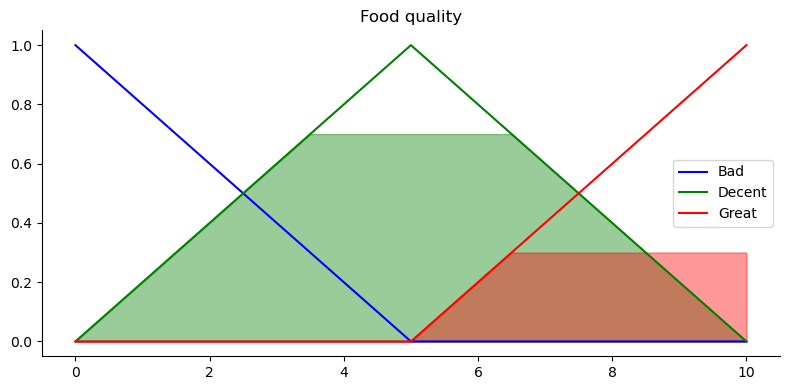

In [ ]:
### we need the activation of our fuzzy membership functions at these values.
# the exact values 6.5 and 9.8 do not exist on our universes.
# The fuzz.interp_membership is just the iterpolation...
qual_level_lo = fuzz.interp_membership(domain_quality, qual_lo_func, 6.5)
qual_level_md = fuzz.interp_membership(domain_quality, qual_md_func, 6.5)
qual_level_hi = fuzz.interp_membership(domain_quality, qual_hi_func, 6.5)

print('Food quality membership values')
print('Bad: ',qual_level_lo)
print('Decent: ',qual_level_md)
print('Great: ',qual_level_hi)

# visualize these universes and membership functions
fig, ax0 = plt.subplots(nrows=1, figsize=(8, 4))

ax0.plot(domain_quality, qual_lo_func, 'b', linewidth=1.5, label='Bad')
qual_lo_degree = np.minimum(qual_lo_func,qual_level_lo)
ax0.fill_between(domain_quality,qual_lo_degree,color="blue",alpha=0.4)

ax0.plot(domain_quality, qual_md_func, 'g', linewidth=1.5, label='Decent')
qual_md_degree = np.minimum(qual_md_func,qual_level_md)
ax0.fill_between(domain_quality,qual_md_degree,color="green",alpha=0.4)

ax0.plot(domain_quality, qual_hi_func, 'r', linewidth=1.5, label='Great')
qual_hi_degree = np.minimum(qual_hi_func,qual_level_hi)
ax0.fill_between(domain_quality,qual_hi_degree,color="red",alpha=0.4)

ax0.set_title('Food quality')
ax0.legend()

# turn off top/right axes
for ax in (ax0, ax1):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

Service membership values
Bad:  0.0
Decent:  0.039999999999999855
Great:  0.9600000000000002


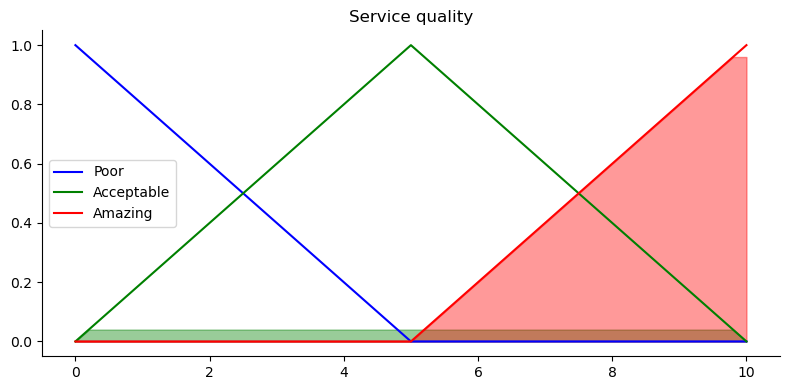

In [ ]:
# we need the activation of our fuzzy membership functions at these values.
# the exact values 6.5 and 9.8 do not exist on our universes...
# this is what fuzz.interp_membership exists for!
serv_level_lo = fuzz.interp_membership(domain_service, serv_lo_func, 9.8)
serv_level_md = fuzz.interp_membership(domain_service, serv_md_func, 9.8)
serv_level_hi = fuzz.interp_membership(domain_service, serv_hi_func, 9.8)

print('Service membership values')
print('Bad: ',serv_level_lo)
print('Decent: ',serv_level_md)
print('Great: ',serv_level_hi)

# visualize these universes and membership functions
fig, ax1 = plt.subplots(nrows=1, figsize=(8, 4))

ax1.plot(domain_service, serv_lo_func, 'b', linewidth=1.5, label='Poor')
serv_lo_degree = np.minimum(serv_lo_func, serv_level_lo)
ax1.fill_between(domain_service, serv_lo_degree,color="blue",alpha=0.4)

ax1.plot(domain_service, serv_md_func, 'g', linewidth=1.5, label='Acceptable')
serv_md_degree = np.minimum(serv_md_func, serv_level_md)
ax1.fill_between(domain_service, serv_md_degree,color="green",alpha=0.4)

ax1.plot(domain_service, serv_hi_func, 'r', linewidth=1.5, label='Amazing')
serv_hi_degree = np.minimum(serv_hi_func, serv_level_hi)
ax1.fill_between(domain_service, serv_hi_degree,color="red",alpha=0.4)

ax1.set_title('Service quality')
ax1.legend()

# turn off top/right axes
for ax in (ax0, ax1):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

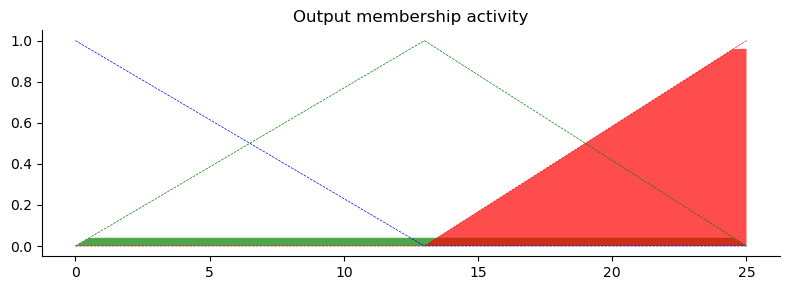

In [ ]:
# now we take our rules and apply them. 
# rule 1 concerns bad food OR service.
# the OR operator means we take the maximum of these two.
active_rule1 = np.fmax(qual_level_lo, serv_level_lo)

# Remark: The np.fmax()  returns the element-wise maximum between 2 arrays. (this the line above, just 2 numbers, it's the same as max())

# now we apply this by clipping the top off the corresponding output
# membership function with `np.fmin`
tip_activation_lo = np.fmin(active_rule1, tip_lo_func)  # removed entirely to 0

# for rule 2 we connect acceptable service to medium tipping
tip_activation_md = np.fmin(serv_level_md, tip_md_func)

# for rule 3 we connect high service OR high food with high tipping
active_rule3 = np.fmax(qual_level_hi, serv_level_hi)
tip_activation_hi = np.fmin(active_rule3, tip_hi_func)
tip0 = np.zeros_like(domain_tip)

# visualize this
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.fill_between(domain_tip, tip0, tip_activation_lo, facecolor='b', alpha=0.7)
ax0.plot(domain_tip, tip_lo_func, 'b', linewidth=0.5, linestyle='--', )
ax0.fill_between(domain_tip, tip0, tip_activation_md, facecolor='g', alpha=0.7)
ax0.plot(domain_tip, tip_md_func, 'g', linewidth=0.5, linestyle='--')
ax0.fill_between(domain_tip, tip0, tip_activation_hi, facecolor='r', alpha=0.7)
ax0.plot(domain_tip, tip_hi_func, 'r', linewidth=0.5, linestyle='--')
ax0.set_title('Output membership activity')

# turn off top/right axes
for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

**Rule aggregation and defuzzification**

Lets combine these rules then defuzzify to get a crisp answer from our fuzzy result

(101,)
(101,)


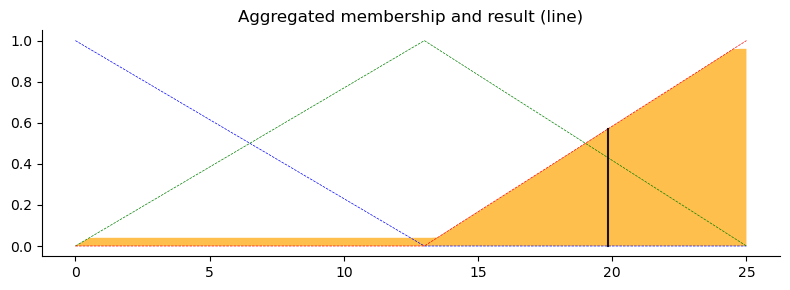

In [10]:
# aggregate all three output membership functions together
aggregated = np.fmax(tip_activation_lo,
                     np.fmax(tip_activation_md, tip_activation_hi))

print(aggregated.shape)
print(domain_tip.shape)

# calculate defuzzified result
tip = fuzz.defuzz(domain_tip, aggregated, 'centroid')
tip_activation = fuzz.interp_membership(domain_tip, aggregated, tip)  # for plot

# visualize this
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.plot(domain_tip, tip_lo_func, 'b', linewidth=0.5, linestyle='--', )
ax0.plot(domain_tip, tip_md_func, 'g', linewidth=0.5, linestyle='--')
ax0.plot(domain_tip, tip_hi_func, 'r', linewidth=0.5, linestyle='--')
ax0.fill_between(domain_tip, tip0, aggregated, facecolor='Orange', alpha=0.7)
ax0.plot([tip, tip], [0, tip_activation], 'k', linewidth=1.5, alpha=0.9)
ax0.set_title('Aggregated membership and result (line)')

# turn off top/right axes
for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()